In [1]:
from preprocessing import load_lang
from preprocessing.text_cleaning import clean_text
from preprocessing.chunking import chunking
import random
import pandas as pd
import re

/home/armotik/miniconda3/envs/codes/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [157]:
results = load_lang("fr", 200)

[FR] Chargement...


In [158]:
texts = random.choices(results, k=100)

In [159]:
df = pd.DataFrame(texts)
df["text"] = df["text"].apply(clean_text)
df["title"] = df["title"].apply(clean_text)

In [160]:
df_chunks = chunking(df, 0)
df_chunks

,text,meta
0,"Le comte Jean Bérenger, conseiller d'État, se ...","{'title': 'Arc de triomphe de l'Étoile', 'doci..."
1,"Le décret impérial du , qui ordonne l'érection...","{'title': 'Arc de triomphe de l'Étoile', 'doci..."
2,"En 1973, la poste célèbre le de la flamme sous...","{'title': 'Arc de triomphe de l'Étoile', 'doci..."
3,Ce petit pays démographiquement parlant a auss...,"{'title': 'Autriche', 'docid': '15#50', 'lang'..."
4,L'espérance de vie en Autriche s'élève à pour ...,"{'title': 'Autriche', 'docid': '15#42', 'lang'..."
...,...,...
228,L'Autriche est une République fédérant neuf Ét...,"{'title': 'Autriche', 'docid': '15#35', 'lang'..."
229,"En 1810, à l'occasion de son mariage avec l'ar...","{'title': 'Arc de triomphe de l'Étoile', 'doci..."
230,"En 1843 , la mathématicienne et pionnière des ...","{'title': 'Algorithmique', 'docid': '10#8', 'l..."
234,"Le substantif ""algorithmique"" désigne l'ensemb...","{'title': 'Algorithmique', 'docid': '10#12', '..."


In [161]:
df["chunk"] = df_chunks["meta"].apply(lambda m: m.get("title", "")) + "\n" + df_chunks["text"]
df

,docid,lang,title,text,chunk
0,16#7,fr,Arc de triomphe de l'Étoile,"Le comte Jean Bérenger, conseiller d'État, se ...",Arc de triomphe de l'Étoile\nLe comte Jean Bér...
1,16#26,fr,Arc de triomphe de l'Étoile,"En 1973, la poste célèbre le de la flamme sous...",Arc de triomphe de l'Étoile\nLe décret impéria...
2,15#50,fr,Autriche,Ce petit pays démographiquement parlant a auss...,"Arc de triomphe de l'Étoile\nEn 1973, la poste..."
3,15#42,fr,Autriche,L'espérance de vie en Autriche s'élève à pour ...,Autriche\nCe petit pays démographiquement parl...
4,15#7,fr,Autriche,"Le fleuve le plus long est le Danube, qui trav...",Autriche\nL'espérance de vie en Autriche s'élè...
...,...,...,...,...,...
95,10#12,fr,Algorithmique,"Le substantif ""algorithmique"" désigne l'ensemb...",Arc de triomphe de l'Étoile\nPlusieurs médias ...
96,16#50,fr,Arc de triomphe de l'Étoile,"L'usage d'un ciment classique était à rejeter,...",Arc de triomphe de l'Étoile\nLe photo-reporter...
97,18#4,fr,Arsène Lupin,Sa célébrité à l'étranger lui vaut tant des ad...,Arc de triomphe de l'Étoile\nDes images sur le...
98,15#39,fr,Autriche,La croissance fut de en 2005. Le taux moyen de...,Politique en Argentine\nLes élections présiden...


In [138]:
def nettoyer_texte(texte):
    if not isinstance(texte, str):
        return ""

    import re, unicodedata

    # Normalisation unicode
    texte = unicodedata.normalize('NFKC', texte)

    # Remplacement des guillemets typographiques par des guillemets simples
    texte = texte.replace('“', '"').replace('”', '"').replace('«', '"').replace('»', '"').replace("’", "'")

    # Remplacer \n par un espace (ou un point + espace si ça coupe une phrase)
    texte = texte.replace('\n', '. ')

    # Supprimer les caractères de contrôle invisibles (hors \n déjà géré)
    texte = re.sub(r'[\x00-\x1F\x7F-\x9F]', '', texte)

    # Supprimer les espaces multiples
    texte = texte.replace('\\n', ' ').replace('\n', ' ')
    texte = re.sub(r'\s+', ' ', texte)

    # Nettoyage des séquences de ponctuation
    texte = re.sub(r'\.{2,}', '.', texte)
    texte = re.sub(r'\?{2,}', '?', texte)
    texte = re.sub(r'\!{2,}', '!', texte)

    # Espaces autour de la ponctuation
    texte = re.sub(r'\s+([.,!?;:])', r'\1', texte)
    texte = re.sub(r'([.,!?;:])([^\s])', r'\1 \2', texte)

    # Suppression des balises ou entités HTML
    texte = re.sub(r'<[^>]+>', '', texte)
    texte = re.sub(r'&\w+;', '', texte)

    # Supprimer les caractères non imprimables ou symboles orphelins
    texte = re.sub(r'[^\x20-\x7EÀ-ÿ€£$¥•–—’“”…°²³µ·]', '', texte)

    return texte.strip()


In [162]:
df["cleaned_text"] = df["chunk"].apply(nettoyer_texte)

In [163]:
df_benchmark = pd.DataFrame({
    "chunk": df["chunk"],
    "cleaned_text": df["cleaned_text"],
    "longueur_origine": df["chunk"].apply(lambda x: len(str(x))),
    "longueur_nettoyee": df["cleaned_text"].apply(len)
})

df_benchmark

,chunk,cleaned_text,longueur_origine,longueur_nettoyee
0,Arc de triomphe de l'Étoile\nLe comte Jean Bér...,Arc de triomphe de l'Étoile. Le comte Jean Bér...,148,149
1,Arc de triomphe de l'Étoile\nLe décret impéria...,Arc de triomphe de l'Étoile. Le décret impéria...,119,118
2,"Arc de triomphe de l'Étoile\nEn 1973, la poste...","Arc de triomphe de l'Étoile. En 1973, la poste...",131,132
3,Autriche\nCe petit pays démographiquement parl...,Autriche. Ce petit pays démographiquement parl...,210,210
4,Autriche\nL'espérance de vie en Autriche s'élè...,Autriche. L'espérance de vie en Autriche s'élè...,87,88
...,...,...,...,...
95,Arc de triomphe de l'Étoile\nPlusieurs médias ...,Arc de triomphe de l'Étoile. Plusieurs médias ...,116,117
96,Arc de triomphe de l'Étoile\nLe photo-reporter...,Arc de triomphe de l'Étoile. Le photo-reporter...,182,183
97,Arc de triomphe de l'Étoile\nDes images sur le...,Arc de triomphe de l'Étoile. Des images sur le...,226,228
98,Politique en Argentine\nLes élections présiden...,Politique en Argentine. Les élections présiden...,85,86


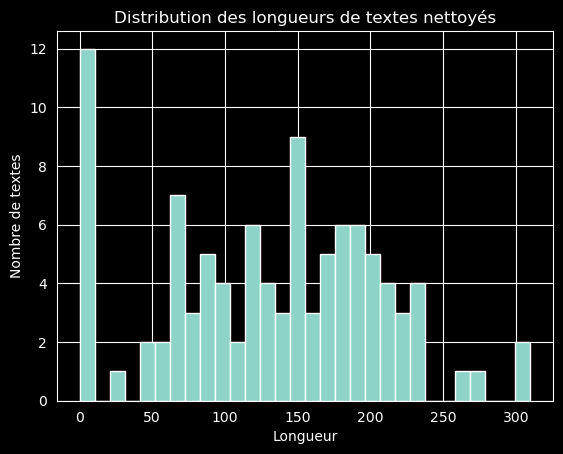

In [164]:
import matplotlib.pyplot as plt

plt.hist(df_benchmark["longueur_nettoyee"], bins=30)
plt.title("Distribution des longueurs de textes nettoyés")
plt.xlabel("Longueur")
plt.ylabel("Nombre de textes")
plt.show()


In [165]:
très_courts = df_benchmark[df_benchmark["longueur_nettoyee"] < 20]
très_courts

,chunk,cleaned_text,longueur_origine,longueur_nettoyee
51,NaN,,3,0
60,NaN,,3,0
61,NaN,,3,0
62,NaN,,3,0
70,NaN,,3,0
71,NaN,,3,0
83,NaN,,3,0
84,NaN,,3,0
85,NaN,,3,0
86,NaN,,3,0


In [166]:
df_benchmark.dropna(inplace=True)

In [167]:
très_longs = df_benchmark[df_benchmark["longueur_nettoyee"] > 300]
très_longs

,chunk,cleaned_text,longueur_origine,longueur_nettoyee
39,Algèbre linéaire\nSi son œuvre reste grandemen...,Algèbre linéaire. Si son uvre reste grandement...,310,310
82,"Algorithmique\nAinsi, pour trier un tableau de...","Algorithmique. Ainsi, pour trier un tableau de...",302,302


In [91]:
import time
from sklearn.metrics import classification_report
from collections import defaultdict
import spacy_transformers
import spacy
from flair.data import Sentence
from flair.models import SequenceTagger
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForTokenClassification

import fr_dep_news_trf

In [67]:
!pip install spacy[transformers]
!python -m spacy download fr_core_news_sm
!python -m spacy download fr_dep_news_trf

/bin/bash: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 796.5/796.5 kB 3.9 MB/s eta 0:00:00a 0:00:01
/bin/bash: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 13.9 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
/bin/bash: warning: setlocale: LC_ALL: cannot change locale (en_US.UTF-8)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 397.7/397.7 MB 17.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 734.0/734.0 kB 12.1 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.30.2
    Uninstalling protobuf-6.30.2:
      Successfully uninstalled protobuf-6.30.2
✔ Download and installation successful
You can now load the package via spacy.load('fr_dep_news_trf')


In [201]:
nlp_sm = spacy.load("fr_core_news_sm")
nlp_trf = spacy.load("fr_dep_news_trf")
fair_ner = SequenceTagger.load("flair/ner-french")

tokenizer = AutoTokenizer.from_pretrained("dslim/bert-large-NER")
model = AutoModelForTokenClassification.from_pretrained("dslim/bert-large-NER")
bert_ner = pipeline("ner", model=model, tokenizer=tokenizer, aggregation_strategy="simple")

2025-04-24 15:28:06,569 SequenceTagger predicts: Dictionary with 19 tags: O, S-LOC, B-LOC, E-LOC, I-LOC, S-PER, B-PER, E-PER, I-PER, S-MISC, B-MISC, E-MISC, I-MISC, S-ORG, B-ORG, E-ORG, I-ORG, <START>, <STOP>


Some weights of the model checkpoint at dslim/bert-large-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


In [202]:
texts = df["cleaned_text"].dropna().tolist()
len(texts)

100

In [203]:
models = {
    "spacy_sm": nlp_sm,
    "spacy_trf": nlp_trf,
    "flair": fair_ner,
    "bert": bert_ner
}
models = {k: v for k, v in models.items() if v is not None}
print(f"✅ Modèles disponibles : {list(models.keys())}")

✅ Modèles disponibles : ['spacy_sm', 'spacy_trf', 'flair', 'bert']


In [204]:
results_summary = []
per_text_results = []

In [205]:
def benchmark_ner(model_name, model_obj, texts):
    results = []
    total_time = 0

    for text in texts:
        start = time.time()
        if model_name == "spacy_sm":
            doc = model_obj(text)
            entities = [(ent.text, ent.label_) for ent in doc.ents]
        elif model_name == "spacy_trf":
            doc = model_obj(text)
            entities = [(ent.text, ent.label_) for ent in doc.ents]
        elif model_name == "flair":
            sentence = Sentence(text)
            model_obj.predict(sentence)
            entities = [(entity.text, entity.tag) for entity in sentence.get_spans('ner')]
        elif model_name == "bert":
            entities = [(ent['word'], ent['entity_group']) for ent in model_obj(text)]
        else:
            entities = []
        end = time.time()
        results.append({
            "text": text,
            "entities": entities,
            "nb_entities": len(entities),
            "processing_time": end - start
        })
        total_time += (end - start)
    return results, total_time

In [206]:
for model_name, model_obj in models.items():
    print(f"🚀 Test du modèle : {model_name}")
    results, total_time = benchmark_ner(model_name, model_obj, texts)
    nb_ents = [r["nb_entities"] for r in results]
    avg_len = sum(len(t) for t in texts) / len(texts)
    avg_ents = sum(nb_ents) / len(nb_ents)

    for i, r in enumerate(results):
        per_text_results.append({
            "text": r["text"],
            "longueur": len(r["text"]),
            "model": model_name,
            "entities": r["entities"],
            "nb_entities": r["nb_entities"],
            "processing_time": r["processing_time"]
        })

    results_summary.append({
        "model": model_name,
        "avg_text_length": avg_len,
        "avg_entities": avg_ents,
        "total_time": round(total_time, 2),
        "avg_time_per_text": round(total_time / len(texts), 4),
        # placeholders pour scores
        "F1": None,
        "Recall": None,
        "Precision": None,
        "TF-IDF": None
    })

🚀 Test du modèle : spacy_sm
🚀 Test du modèle : spacy_trf
🚀 Test du modèle : flair
2025-04-24 15:28:27,440 Warning: An empty Sentence was created! Are there empty strings in your dataset?
2025-04-24 15:28:28,926 Warning: An empty Sentence was created! Are there empty strings in your dataset?
2025-04-24 15:28:28,927 Warning: An empty Sentence was created! Are there empty strings in your dataset?
2025-04-24 15:28:28,927 Warning: An empty Sentence was created! Are there empty strings in your dataset?
2025-04-24 15:28:29,926 Warning: An empty Sentence was created! Are there empty strings in your dataset?
2025-04-24 15:28:29,927 Warning: An empty Sentence was created! Are there empty strings in your dataset?
2025-04-24 15:28:31,878 Warning: An empty Sentence was created! Are there empty strings in your dataset?
2025-04-24 15:28:31,879 Warning: An empty Sentence was created! Are there empty strings in your dataset?
2025-04-24 15:28:31,880 Warning: An empty Sentence was created! Are there empt

In [207]:
benchmark_df = pd.DataFrame(results_summary)
detailed_df = pd.DataFrame(per_text_results)

In [208]:
benchmark_df

,model,avg_text_length,avg_entities,total_time,avg_time_per_text,F1,Recall,Precision,TF-IDF
0,spacy_sm,131.27,1.39,1.41,0.0141,None,None,None,None
1,spacy_trf,131.27,0.00,9.48,0.0948,None,None,None,None
2,flair,131.27,1.66,14.65,0.1465,None,None,None,None
3,bert,131.27,3.34,32.08,0.3208,None,None,None,None


In [209]:
detailed_df

,text,longueur,model,entities,nb_entities,processing_time
0,Arc de triomphe de l'Étoile. Le comte Jean Bér...,149,spacy_sm,"[(Jean Bérenger, PER), (État, LOC), (Caisse, O...",3,0.051454
1,Arc de triomphe de l'Étoile. Le décret impéria...,118,spacy_sm,[],0,0.016425
2,"Arc de triomphe de l'Étoile. En 1973, la poste...",132,spacy_sm,"[(Arc de Triomphe, LOC), (lilas, PER)]",2,0.017045
3,Autriche. Ce petit pays démographiquement parl...,210,spacy_sm,"[(Autriche, LOC), (Formule 1, ORG), (Jochen Ri...",4,0.027324
4,Autriche. L'espérance de vie en Autriche s'élè...,88,spacy_sm,"[(Autriche, LOC), (Autriche, LOC)]",2,0.017168
...,...,...,...,...,...,...
395,Arc de triomphe de l'Étoile. Plusieurs médias ...,117,bert,"[(', ORG), (É, ORG), (##ile, ORG), (Marianne, ...",4,0.344948
396,Arc de triomphe de l'Étoile. Le photo-reporter...,183,bert,"[(de, MISC), (de, MISC), (', ORG), (É, ORG), (...",6,0.333236
397,Arc de triomphe de l'Étoile. Des images sur le...,228,bert,"[(Arc de triomphe, MISC), (de l ' É, LOC), (##...",4,0.383935
398,Politique en Argentine. Les élections présiden...,86,bert,"[(Pol, ORG), (##que, ORG), (en Argentine, MISC)]",3,0.274882


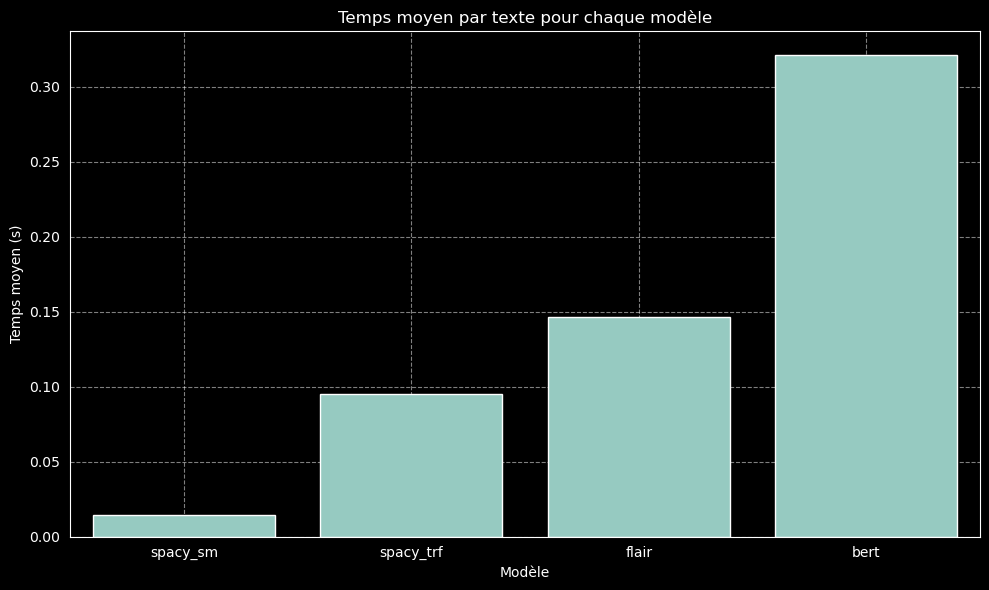

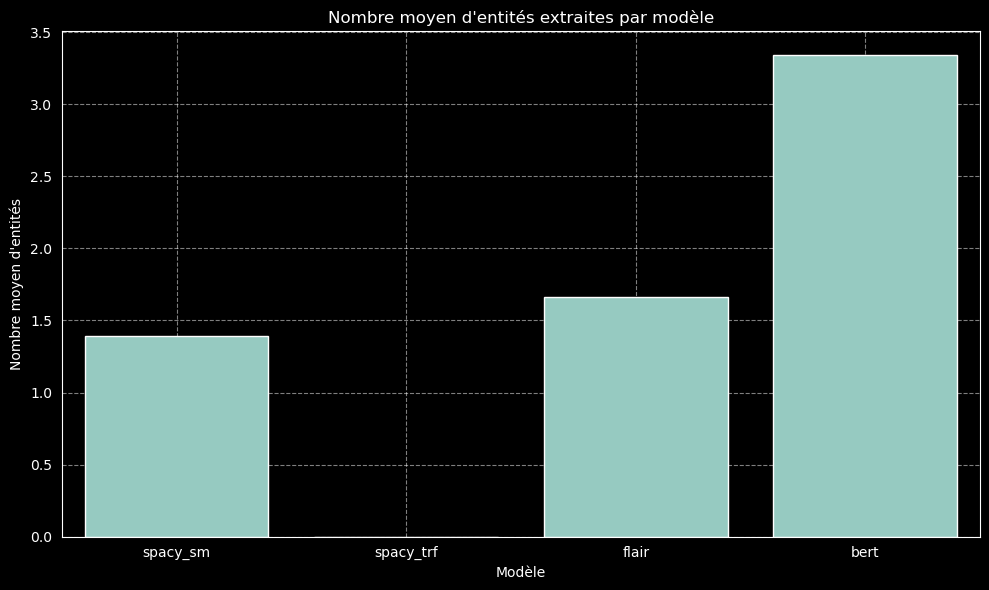

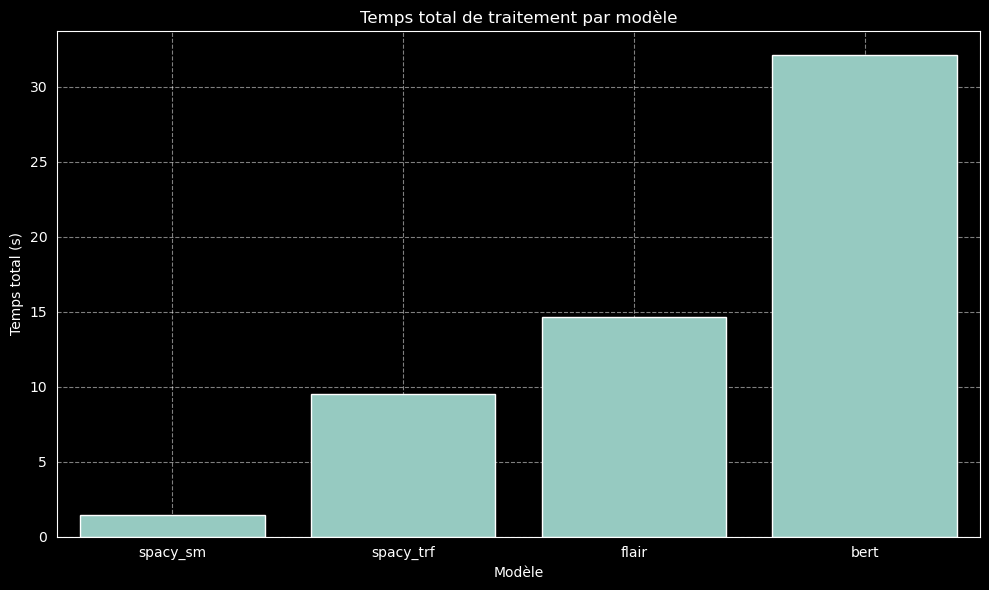

In [210]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du style
plt.style.use("dark_background")

# Graphique 1 : Temps moyen par texte
plt.figure(figsize=(10, 6))
sns.barplot(x="model", y="avg_time_per_text", data=benchmark_df)
plt.title("Temps moyen par texte pour chaque modèle")
plt.ylabel("Temps moyen (s)")
plt.xlabel("Modèle")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Graphique 2 : Nombre moyen d'entités extraites
plt.figure(figsize=(10, 6))
sns.barplot(x="model", y="avg_entities", data=benchmark_df)
plt.title("Nombre moyen d'entités extraites par modèle")
plt.ylabel("Nombre moyen d'entités")
plt.xlabel("Modèle")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Graphique 3 : Temps total de traitement
plt.figure(figsize=(10, 6))
sns.barplot(x="model", y="total_time", data=benchmark_df)
plt.title("Temps total de traitement par modèle")
plt.ylabel("Temps total (s)")
plt.xlabel("Modèle")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [196]:
df_bert = detailed_df[detailed_df["model"] == "bert"]
df_bert

,text,longueur,model,entities,nb_entities,processing_time
0,Arc de triomphe de l'Étoile. Le comte Jean Bér...,149,bert,"[(de, MISC), (de, MISC), (', ORG), (É, ORG), (...",9,0.451341
1,Arc de triomphe de l'Étoile. Le décret impéria...,118,bert,"[(Arc, MISC), (de, MISC), (' É, MISC), (##ile,...",4,0.400443
2,"Arc de triomphe de l'Étoile. En 1973, la poste...",132,bert,"[(Arc, LOC), (de triomphe de, MISC), (l ', LOC...",6,0.459322
3,Autriche. Ce petit pays démographiquement parl...,210,bert,"[(Autriche, ORG), (Formule 1, MISC), (Jo, PER)...",5,0.370181
4,Autriche. L'espérance de vie en Autriche s'élè...,88,bert,"[(Autriche, LOC), (Autriche, LOC)]",2,0.337419
...,...,...,...,...,...,...
95,Arc de triomphe de l'Étoile. Plusieurs médias ...,117,bert,"[(', ORG), (É, ORG), (##ile, ORG), (Marianne, ...",4,0.367340
96,Arc de triomphe de l'Étoile. Le photo-reporter...,183,bert,"[(de, MISC), (de, MISC), (', ORG), (É, ORG), (...",6,0.347132
97,Arc de triomphe de l'Étoile. Des images sur le...,228,bert,"[(Arc de triomphe, MISC), (de l ' É, LOC), (##...",4,0.403958
98,Politique en Argentine. Les élections présiden...,86,bert,"[(Pol, ORG), (##que, ORG), (en Argentine, MISC)]",3,0.297410


In [130]:
def post_traitement_bert_entities(entities):
    cleaned = []
    current = ""
    label = None

    for word, tag in entities:
        if word.startswith("##"):
            current += word[2:]
        else:
            if current:
                cleaned.append((current.strip(), label))
            current = word
            label = tag

    if current:
        cleaned.append((current.strip(), label))

    # Supprimer les entités trop courtes ou visiblement bruitées
    cleaned = [(w, t) for w, t in cleaned if len(w) > 2 and w.lower() not in {"l'", "’", "le", "la"}]

    return cleaned


In [197]:
df_bert.loc[:, "entities"] = df_bert["entities"].apply(post_traitement_bert_entities)
df_bert

,text,longueur,model,entities,nb_entities,processing_time
0,Arc de triomphe de l'Étoile. Le comte Jean Bér...,149,bert,"[(Éile, ORG), (Jean Bérenger, PER), (État, ORG...",9,0.451341
1,Arc de triomphe de l'Étoile. Le décret impéria...,118,bert,"[(Arc, MISC), (' Éile, MISC)]",4,0.400443
2,"Arc de triomphe de l'Étoile. En 1973, la poste...",132,bert,"[(Arc, LOC), (de triomphe de, MISC), (l ', LOC...",6,0.459322
3,Autriche. Ce petit pays démographiquement parl...,210,bert,"[(Autriche, ORG), (Formule 1, MISC), (Jochen R...",5,0.370181
4,Autriche. L'espérance de vie en Autriche s'élè...,88,bert,"[(Autriche, LOC), (Autriche, LOC)]",2,0.337419
...,...,...,...,...,...,...
95,Arc de triomphe de l'Étoile. Plusieurs médias ...,117,bert,"[(Éile, ORG), (Marianne, PER)]",4,0.367340
96,Arc de triomphe de l'Étoile. Le photo-reporter...,183,bert,"[(Éile, ORG), (Jean - René Santini, PER)]",6,0.347132
97,Arc de triomphe de l'Étoile. Des images sur le...,228,bert,"[(Arc de triomphe, MISC), (de l ' Éile, LOC), ...",4,0.403958
98,Politique en Argentine. Les élections présiden...,86,bert,"[(Polque, ORG), (en Argentine, MISC)]",3,0.297410


In [179]:
nlp_fr = spacy.load("fr_core_news_sm")
nlp_en = spacy.load("en_core_web_sm")

In [180]:
def reclasse_entity(entity_text, lang="fr"):
    nlp = nlp_fr if lang == "fr" else nlp_en
    doc = nlp(entity_text)
    ents = [(ent.text, ent.label_) for ent in doc.ents]
    return ents

In [199]:
def post_traitement_mist(entities, text_lang="fr"):
    final_entities = []
    for ent_text, ent_label in entities:
        if ent_label == "MISC":
            new_ents = reclasse_entity(ent_text, text_lang)
            if not new_ents:
                continue  # Supprimer si non reconnu

            final_entities.append((ent_text, ent_label)) # Conserver l'original
            final_entities.extend(new_ents)
        else:
            final_entities.append((ent_text, ent_label))
    return final_entities

In [200]:
df_bert["new_entities"] = df_bert["entities"].apply(post_traitement_mist)
df_bert

,text,longueur,model,entities,nb_entities,processing_time,new_entities
0,Arc de triomphe de l'Étoile. Le comte Jean Bér...,149,bert,"[(Éile, ORG), (Jean Bérenger, PER), (État, ORG...",9,0.451341,"[(Éile, ORG), (Jean Bérenger, PER), (État, ORG..."
1,Arc de triomphe de l'Étoile. Le décret impéria...,118,bert,"[(Arc, MISC), (' Éile, MISC)]",4,0.400443,"[(Arc, MISC), (Arc, LOC), (' Éile, MISC), (Éil..."
2,"Arc de triomphe de l'Étoile. En 1973, la poste...",132,bert,"[(Arc, LOC), (de triomphe de, MISC), (l ', LOC...",6,0.459322,"[(Arc, LOC), (l ', LOC), (Éile, LOC), (Arc de ..."
3,Autriche. Ce petit pays démographiquement parl...,210,bert,"[(Autriche, ORG), (Formule 1, MISC), (Jochen R...",5,0.370181,"[(Autriche, ORG), (Formule 1, MISC), (Formule ..."
4,Autriche. L'espérance de vie en Autriche s'élè...,88,bert,"[(Autriche, LOC), (Autriche, LOC)]",2,0.337419,"[(Autriche, LOC), (Autriche, LOC)]"
...,...,...,...,...,...,...,...
95,Arc de triomphe de l'Étoile. Plusieurs médias ...,117,bert,"[(Éile, ORG), (Marianne, PER)]",4,0.367340,"[(Éile, ORG), (Marianne, PER)]"
96,Arc de triomphe de l'Étoile. Le photo-reporter...,183,bert,"[(Éile, ORG), (Jean - René Santini, PER)]",6,0.347132,"[(Éile, ORG), (Jean - René Santini, PER)]"
97,Arc de triomphe de l'Étoile. Des images sur le...,228,bert,"[(Arc de triomphe, MISC), (de l ' Éile, LOC), ...",4,0.403958,"[(de l ' Éile, LOC), (Arc de Triomphe, MISC), ..."
98,Politique en Argentine. Les élections présiden...,86,bert,"[(Polque, ORG), (en Argentine, MISC)]",3,0.297410,"[(Polque, ORG), (en Argentine, MISC), (Argenti..."
